In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
%pip install rdkit imbalanced-learn xgboost shap scikit-learn pandas numpy matplotlib seaborn pubchempy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import warnings
import os, glob, zipfile
warnings.filterwarnings('ignore')

print('Imports done.')

Imports done.


## Load and extract ChEMBL data

In [4]:
import os, glob
import pandas as pd

DATA_DIR = 'data'      # put the ChEMBL exports (DOWNLOAD-*.csv) here
FOLDER = 'Results'     # figures and other outputs are saved here
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FOLDER, exist_ok=True)

# Load CSVs
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, 'DOWNLOAD-*.csv')))
assert csv_files, f'No DOWNLOAD-*.csv files found in {os.path.abspath(DATA_DIR)}. Copy your ChEMBL exports there.'
print(f'Found {len(csv_files)} CSV files')

dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep=';', quotechar='"', low_memory=False)
    dfs.append(df)
    print(f'  {os.path.basename(f)[:50]} -> {len(df)} rows')

df_chembl_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal records: {len(df_chembl_raw)}')

# Clean
df_chembl_raw = df_chembl_raw.rename(columns={'Smiles': 'smiles', 'Molecule ChEMBL ID': 'name'})
df_chembl_raw = df_chembl_raw[['name', 'smiles', 'Standard Type', 'Standard Value', 'Standard Units']].copy()
df_chembl_raw = df_chembl_raw.dropna(subset=['smiles'])
df_chembl_raw = df_chembl_raw[~df_chembl_raw['smiles'].str.contains(r'\.', na=False)]

# Label
def assign_label(row):
    stype = str(row['Standard Type']).strip()
    try:
        val = float(str(row['Standard Value']).replace("'", '').strip())
    except (ValueError, TypeError):
        return None
    if stype in ['Delta Tm', 'deltaTm1/2']:
        return 1 if val >= 5.0 else 0
    elif stype in ['IC50', 'Kd', 'DC50']:
        units = str(row['Standard Units'])
        if 'nM' in units:
            return 1 if val <= 10000 else 0
        elif 'uM' in units or 'microM' in units:
            return 1 if val <= 10.0 else 0
    elif stype == 'Ka':
        return 1 if val >= 1e5 else 0
    elif stype == 'Activity':
        return 1 if val >= 50 else 0
    return None

df_chembl_raw['label'] = df_chembl_raw.apply(assign_label, axis=1)
df_chembl_raw = df_chembl_raw.dropna(subset=['label'])
df_chembl_raw['label'] = df_chembl_raw['label'].astype(int)

# Duplicates: drop compounds whose records disagree on the label, keep one record otherwise
label_nunique = df_chembl_raw.groupby('smiles')['label'].transform('nunique')
n_conflict = df_chembl_raw.loc[label_nunique > 1, 'smiles'].nunique()
df_chembl_raw = df_chembl_raw[label_nunique == 1].drop_duplicates('smiles')
print(f'Removed {n_conflict} compounds with conflicting labels')

print(f'After cleaning: {len(df_chembl_raw)} unique compounds')
print(f'  Active:   {df_chembl_raw.label.sum()}')
print(f'  Inactive: {(df_chembl_raw.label==0).sum()}')

# Label counts per assay type (for the README)
print('\nLabels by assay type:')
print(df_chembl_raw.groupby('Standard Type')['label'].agg(n='count', actives='sum'))

Found 3 CSV files
  DOWNLOAD-0uUznu9aDg3xX_oKI4x5m5QiIlWPIRxYT644IJAdh -> 84 rows
  DOWNLOAD-6hftHMwg5klrBPmSgE3lxoSJyJRuu7CB5Y_Ye7N3O -> 318 rows
  DOWNLOAD-otnsPmT1WrGjsqFWTuo0T4eDQs7hyCVrN1OtaFzfP -> 3760 rows

Total records: 4162
Removed 228 compounds with conflicting labels
After cleaning: 348 unique compounds
  Active:   180
  Inactive: 168

Labels by assay type:
                 n  actives
Standard Type              
Activity        80        9
DC50             2        2
Delta Tm       231      149
IC50             1        1
Ka               6        0
Kd              21       18
deltaTm1/2       7        1


In [5]:
# Analysis switch
# True : single-assay labels only (Delta Tm >= 5 C), 250 compounds
# False: all assay types with the label rules above, 367 compounds
DELTA_TM_ONLY = False
if DELTA_TM_ONLY:
    df_chembl_raw = df_chembl_raw[df_chembl_raw['Standard Type'] == 'Delta Tm']


OK      Pyridostatin
OK      BRACO19
OK      Berberine
OK      Ellipticine
OK      Cryptolepine
OK      Quindoline
OK      Doxorubicin
OK      Mitoxantrone
OK      Aspirin
OK      Metformin
OK      Paracetamol
OK      Ibuprofen
OK      Caffeine
OK      Metoprolol
OK      Omeprazole
OK      Warfarin
OK      Fluorouracil
OK      Gabapentin
OK      Valproic_acid
19 curated compounds | skipped: []


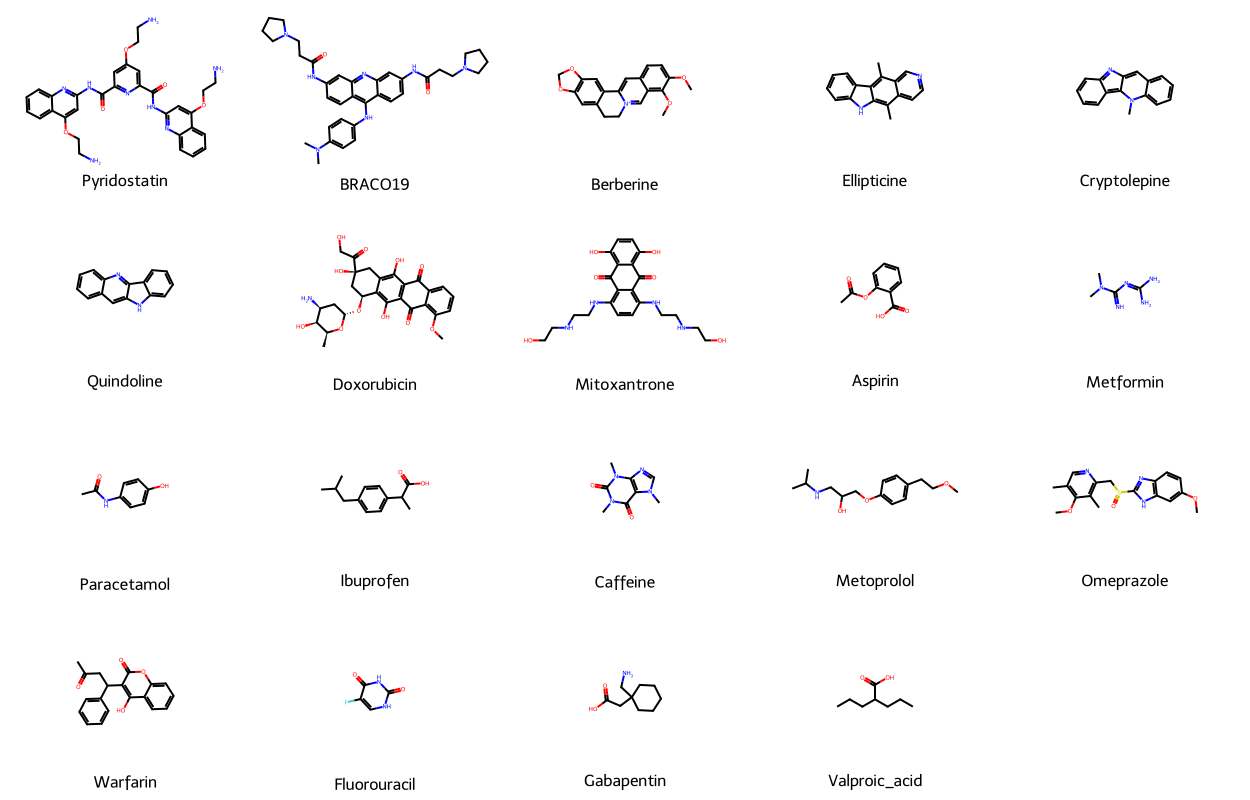

Final dataset: 367 compounds
  Active:   188
  Inactive: 179
source
ChEMBL     348
Curated     19
Name: count, dtype: int64


In [6]:
import pubchempy as pcp
from rdkit import Chem

# (name in dataset, PubChem search name, label)
curated_names = [
    ('Pyridostatin',  'pyridostatin',  1),   # PDS is the same drug, so one entry only
    ('BRACO19',       'BRACO-19',      1),
    ('Berberine',     'berberine',     1),
    ('Ellipticine',   'ellipticine',   1),
    ('Cryptolepine',  'cryptolepine',  1),
    ('Quindoline',    'quindoline',    1),
    ('Doxorubicin',   'doxorubicin',   1),
    ('Mitoxantrone',  'mitoxantrone',  1),
    ('Aspirin',       'aspirin',       0),
    ('Metformin',     'metformin',     0),
    ('Paracetamol',   'acetaminophen', 0),
    ('Ibuprofen',     'ibuprofen',     0),
    ('Caffeine',      'caffeine',      0),
    ('Metoprolol',    'metoprolol',    0),
    ('Omeprazole',    'omeprazole',    0),
    ('Warfarin',      'warfarin',      0),
    ('Fluorouracil',  'fluorouracil',  0),
    ('Gabapentin',    'gabapentin',    0),
    ('Valproic_acid', 'valproic acid', 0),
]

import time
from IPython.display import display
from rdkit.Chem import Draw

def pubchem_smiles(query, tries=4):
    for attempt in range(tries):
        try:
            hits = pcp.get_compounds(query, 'name')
            if not hits:
                return None
            for attr in ('smiles', 'isomeric_smiles', 'canonical_smiles'):
                v = getattr(hits[0], attr, None)
                if v:
                    return v
            return None
        except Exception as e:
            wait = 3 * (attempt + 1)
            print(f'  {query}: {type(e).__name__}, retrying in {wait}s')
            time.sleep(wait)
    return None

curated, skipped = [], []
for name, query, label in curated_names:
    smi = pubchem_smiles(query)
    time.sleep(0.5)                      # stay under PubChem's request limit
    if smi is None or Chem.MolFromSmiles(smi) is None:
        skipped.append(name)
        print(f'SKIPPED {name}')
        continue
    curated.append((name, smi, label))
    print(f'OK      {name}')
print(len(curated), 'curated compounds | skipped:', skipped)

display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for _, s, _ in curated],
                             legends=[n for n, _, _ in curated],
                             molsPerRow=5, subImgSize=(250, 200)))

df_curated = pd.DataFrame(curated, columns=['name', 'smiles', 'label'])

# Merge ChEMBL + curated
df_chembl_clean = df_chembl_raw[['name', 'smiles', 'label']].copy()
df_chembl_clean['source'] = 'ChEMBL'

df_curated['source'] = 'Curated'

df_combined = pd.concat([df_chembl_clean, df_curated], ignore_index=True)
df_combined = df_combined.drop_duplicates('smiles')

print(f'Final dataset: {len(df_combined)} compounds')
print(f'  Active:   {df_combined.label.sum()}')
print(f'  Inactive: {(df_combined.label==0).sum()}')
print(df_combined['source'].value_counts())

## Feature engineering

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit import DataStructs

def smiles_to_features(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    fp_arr = np.zeros(n_bits, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    physchem = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
    ], dtype=np.float32)
    return np.concatenate([fp_arr, physchem])

print('Computing features...')
features, valid_idx = [], []

for i, row in df_combined.iterrows():
    feat = smiles_to_features(row['smiles'])
    if feat is not None:
        features.append(feat)
        valid_idx.append(i)

X = np.array(features)
y = df_combined.loc[valid_idx, 'label'].values

print(f'Feature matrix: {X.shape}')
print(f'Active: {y.sum()} | Inactive: {(y==0).sum()}')

Computing features...
Feature matrix: (367, 2055)
Active: 188 | Inactive: 179


## Train/test split, SMOTE, model training

In [8]:
import numpy as np
from collections import Counter
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

X = np.asarray(X)
y = np.asarray(y)

# ---- 1. Scaffold groups ----
smiles_list = df_combined.loc[valid_idx, 'smiles'].tolist()

def scaffold(smi):
    scaf = MurckoScaffold.MurckoScaffoldSmiles(smiles=smi)
    return scaf if scaf else smi          # molecules without rings form their own group

groups = np.array([scaffold(s) for s in smiles_list])
print('Unique scaffolds:', len(set(groups)))

# ---- 2. Scaffold-based train/test split ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train = groups[train_idx]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('Train classes:', Counter(y_train), '| Test classes:', Counter(y_test))
print('Scaffold overlap between train and test:', len(set(g_train) & set(groups[test_idx])))   # must be 0

USE_SMOTE = False   # False = no oversampling (ablation), True = original setup

def make_pipe(clf, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    if USE_SMOTE:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

MODELS = {
    'Logistic Regression': make_pipe(LogisticRegression(max_iter=1000, random_state=42), scale=True),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'XGBoost':             make_pipe(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                                   random_state=42, eval_metric='logloss', verbosity=0)),
    'SVM':                 make_pipe(SVC(kernel='rbf', probability=True, random_state=42), scale=True),
}

# ---- 4. Scaffold-grouped 5-fold CV on the training set ----
cv = GroupKFold(n_splits=5)
cv_results = {}
for name, model in MODELS.items():
    scores = cross_validate(model, X_train, y_train, groups=g_train, cv=cv,
                            scoring=['roc_auc', 'average_precision', 'f1'], n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: AUC = {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")

best_model_name = max(cv_results, key=lambda m: cv_results[m]['test_roc_auc'].mean())
print('Best model:', best_model_name)

Unique scaffolds: 219
Train: (279, 2055) | Test: (88, 2055)
Train classes: Counter({np.int64(1): 149, np.int64(0): 130}) | Test classes: Counter({np.int64(0): 49, np.int64(1): 39})
Scaffold overlap between train and test: 0
Logistic Regression: AUC = 0.913 ± 0.026
Random Forest: AUC = 0.940 ± 0.023
XGBoost: AUC = 0.903 ± 0.037
SVM: AUC = 0.908 ± 0.035
Best model: Random Forest


## Test Set Evaluation

=== Test Set: Random Forest ===
AUC-ROC: 0.905
AUPRC:   0.922

              precision    recall  f1-score   support

    Inactive       0.85      0.80      0.82        49
      Active       0.76      0.82      0.79        39

    accuracy                           0.81        88
   macro avg       0.80      0.81      0.81        88
weighted avg       0.81      0.81      0.81        88



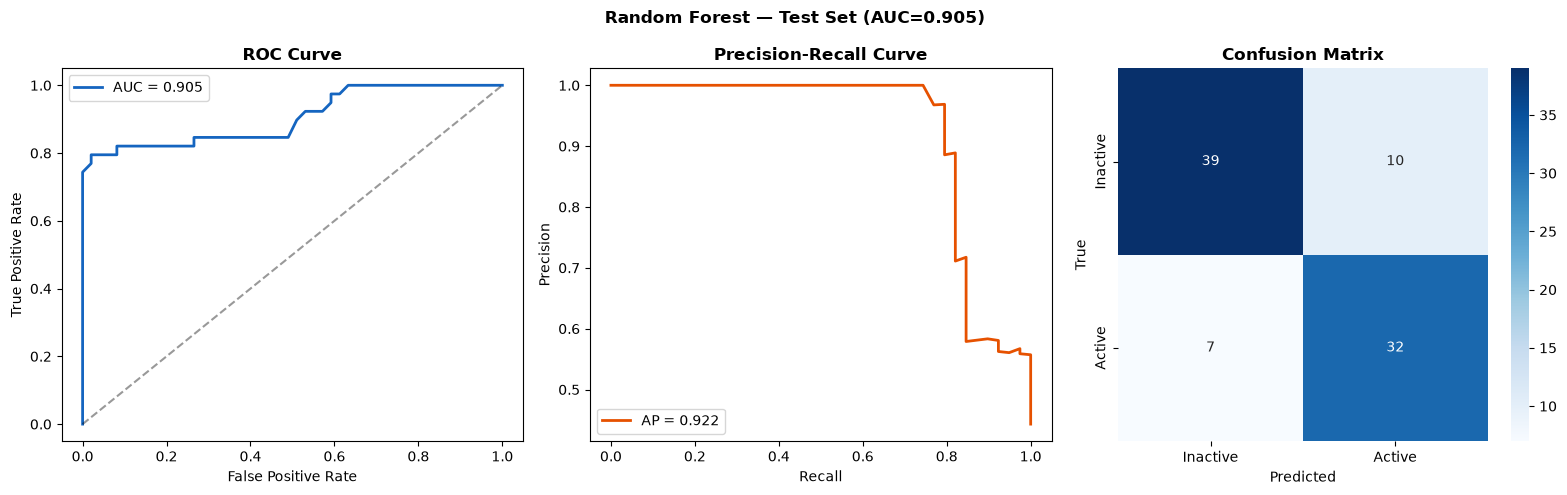

Saved: test_evaluation.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)

# Fit best model
best_model = MODELS[best_model_name]
best_model.fit(X_train, y_train)   # SMOTE is applied inside the pipeline

# Predict
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)
ap_score  = average_precision_score(y_test, y_prob)

print(f'=== Test Set: {best_model_name} ===')
print(f'AUC-ROC: {auc_score:.3f}')
print(f'AUPRC:   {ap_score:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Inactive', 'Active']))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#E65100', lw=2, label=f'AP = {ap_score:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Inactive','Active'],
            yticklabels=['Inactive','Active'])
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('True')
axes[2].set_xlabel('Predicted')

fig.suptitle(f'{best_model_name} — Test Set (AUC={auc_score:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_evaluation.png')

In [10]:
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score

rs = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=0)
aucs, aps = [], []
for tr, te in rs.split(X, y, groups):
    if len(set(y[te])) < 2:
        continue
    m = clone(MODELS[best_model_name]).fit(X[tr], y[tr])
    p = m.predict_proba(X[te])[:, 1]
    aucs.append(roc_auc_score(y[te], p))
    aps.append(average_precision_score(y[te], p))

print(f'Repeated scaffold splits (n={len(aucs)}): '
      f'AUC {np.mean(aucs):.3f} ± {np.std(aucs):.3f}, '
      f'AUPRC {np.mean(aps):.3f} ± {np.std(aps):.3f}')

Repeated scaffold splits (n=20): AUC 0.937 ± 0.032, AUPRC 0.947 ± 0.027


## SHAP Analysis

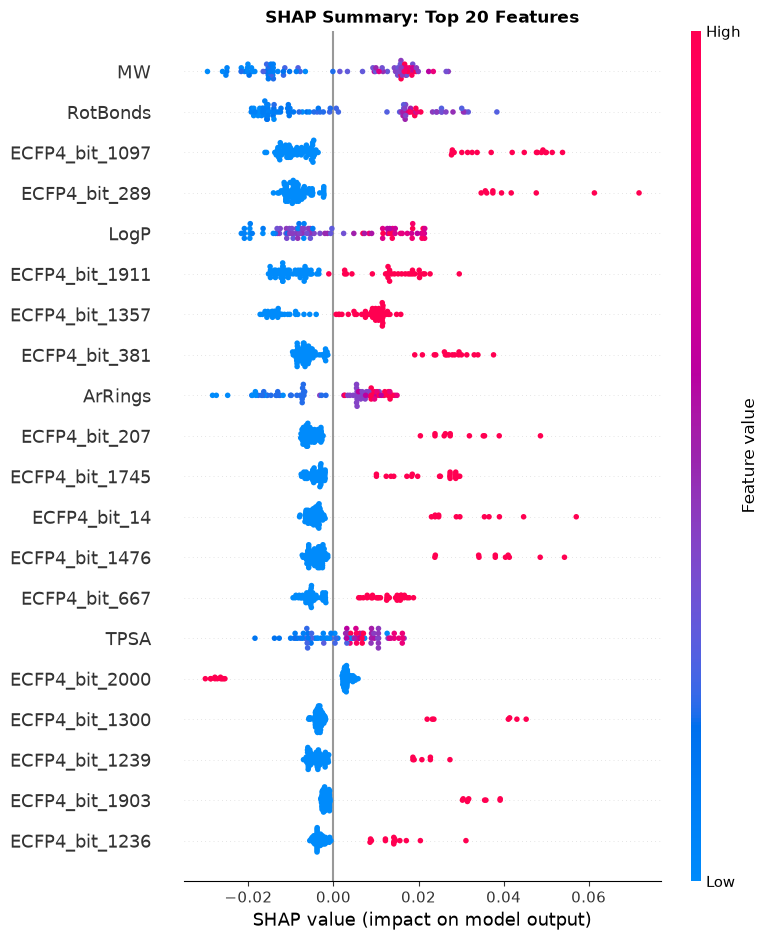

Physicochemical descriptor SHAP importance:
  MW         0.01596
  LogP       0.01193
  TPSA       0.00705
  HBD        0.00233
  HBA        0.00454
  RotBonds   0.01579
  ArRings    0.01035
Top descriptor: MW


In [11]:
import shap

# Feature names (these were defined in the original SHAP cell)
fp_names = [f'ECFP4_bit_{i}' for i in range(2048)]
desc_names = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'ArRings']
all_feature_names = fp_names + desc_names

clf = best_model.named_steps['clf']
sv = shap.TreeExplainer(clf).shap_values(X_test)
sv = sv[1] if isinstance(sv, list) else sv[:, :, 1]   # class "Active"; handles both shap versions

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=all_feature_names, max_display=20, show=False)
plt.title('SHAP Summary: Top 20 Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# Importance of the 7 physicochemical descriptors
mean_shap = np.abs(sv).mean(axis=0)
feat_imp = dict(zip(all_feature_names, mean_shap))
print('Physicochemical descriptor SHAP importance:')
for d in desc_names:
    print(f'  {d:10s} {feat_imp[d]:.5f}')
print('Top descriptor:', max(desc_names, key=lambda d: feat_imp[d]))

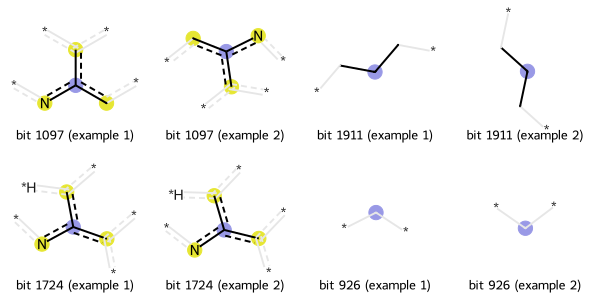

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator
from IPython.display import display

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
smiles_all = df_combined.loc[valid_idx, 'smiles'].tolist()

def examples_for_bit(bit, n=2):
    """Find up to n molecules that set this fingerprint bit."""
    found = []
    for smi in smiles_all:
        mol = Chem.MolFromSmiles(smi)
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        morgan_gen.GetFingerprint(mol, additionalOutput=ao)
        info = ao.GetBitInfoMap()
        if bit in info:
            found.append((mol, bit, info))
            if len(found) == n:
                break
    return found

# Take these from the NEW shap_summary.png after the clean re-run
top_bits = [1097, 1911, 1724, 926]

tuples, legends = [], []
for b in top_bits:
    for k, t in enumerate(examples_for_bit(b, n=2), start=1):
        tuples.append(t)
        legends.append(f'bit {b} (example {k})')

display(Draw.DrawMorganBits(tuples, molsPerRow=4, legends=legends))

## Result Summary

In [13]:
cv_auc = cv_results[best_model_name]['test_roc_auc']

print('=' * 60)
print('  G4 LIGAND CLASSIFIER: FINAL RESULTS')
print('=' * 60)
print(f'  Dataset:      {len(df_combined)} compounds')
print(f'  Features:     2048 ECFP4 bits + 7 physicochemical descriptors')
print(f'  Split:        scaffold-based (train and test share no Murcko scaffolds)')
print(f'  Best model:   {best_model_name}')
print(f'  CV AUC-ROC:   {cv_auc.mean():.3f} ± {cv_auc.std():.3f} (5-fold, grouped by scaffold, SMOTE inside folds)')
print(f'  Test AUC-ROC: {auc_score:.3f}')
print(f'  Test AUPRC:   {ap_score:.3f}')
print()
print('  SHAP: mean |SHAP| of the 7 physicochemical descriptors')
for d in desc_names:
    bar = '█' * int(feat_imp[d] * 500)
    print(f'    {d:12s} {feat_imp[d]:.5f}  {bar}')
print()
print('  See shap_summary.png for the top 20 features across all 2055.')
print('=' * 60)

  G4 LIGAND CLASSIFIER: FINAL RESULTS
  Dataset:      367 compounds
  Features:     2048 ECFP4 bits + 7 physicochemical descriptors
  Split:        scaffold-based (train and test share no Murcko scaffolds)
  Best model:   Random Forest
  CV AUC-ROC:   0.940 ± 0.023 (5-fold, grouped by scaffold, SMOTE inside folds)
  Test AUC-ROC: 0.905
  Test AUPRC:   0.922

  SHAP: mean |SHAP| of the 7 physicochemical descriptors
    MW           0.01596  ███████
    LogP         0.01193  █████
    TPSA         0.00705  ███
    HBD          0.00233  █
    HBA          0.00454  ██
    RotBonds     0.01579  ███████
    ArRings      0.01035  █████

  See shap_summary.png for the top 20 features across all 2055.


In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

size_idx = [2048 + desc_names.index(d) for d in ['MW', 'RotBonds']]
base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
base.fit(X_train[:, size_idx], y_train)
print('MW + RotBonds only, test AUC:', roc_auc_score(y_test, base.predict_proba(X_test[:, size_idx])[:, 1]))

MW + RotBonds only, test AUC: 0.6588173731030875
